In [13]:
#Importing Important Stuff
import os
import cv2
import sys
import math
import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import scipy.interpolate
import scipy.signal
import sklearn.cluster
import fmEphys as fme
import pickle
import sys
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc


def calc_std_modidx(psth,thresh):
 
    psth = psth.astype(float)
    psth = psth - np.nanmean(psth[100:750])

    std_thresh = np.nanstd(psth[100:750]*thresh)
    
    if np.nanmax((np.abs(psth[1000:1350])-std_thresh)) > 0:
        mod = 1
    else:
        mod = 0 
    return mod
    
def calc_fr_modidx(psth,thresh):

    psth = psth.astype(float)
    psth = psth - np.nanmean(psth[100:750])

    if np.nanmax(np.abs(psth[1000:1350])) > thresh:
        mod = 1
    else:
        mod = 0
    return mod

    
def calc_saccade_MM(psth):
    data = psth - np.nanmean(psth[50:750])
    data = data[1000:1350]
    latency = np.argmax(np.abs(data))
    MM = data[latency]
    return MM, latency


def jitter(c, sz, maxdist=0.25):
    """ Jitter x values.

    This is useful for scatter plots of categorical data,
    when the distribution along y is more clear when the
    x position of that category is jittered slightly.

    Parameters
    ----------
    c : int or float
        Center position of the data.
    sz : int
        Number of data points.
    maxdist : float
        Maximum distance that a value can be jittered
        from their center point, `c`.

    Returns
    -------
    j_x : np.array
        Jittered x values in a 1D array of length `sz`.

    """

    j_x = np.ones(sz) + np.random.uniform(c-maxdist, c+maxdist, sz)

    return j_x

In [66]:
RecordingsToUse = [r'F:\Science\Freely Moving Ephys\DOI Mice\101724\G6CK10JRT',
                   r'F:\Science\Freely Moving Ephys\DOI Mice\102624\J722LT',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\013125\G6CK14BLN',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\021225',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\022725\G6CK14BTT',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\052125\G6CK14GTT',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\060625\J748RT',
                  r'I:\111524\J715RT']

In [14]:
RecordingsToUse = [r'F:\Science\Freely Moving Ephys\DOI Mice\101724\G6CK10JRT',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\022725\G6CK14BTT',
                   r'\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\060625\J748RT',
                   r'I:\111524\J715RT']

In [67]:
Data = pd.DataFrame()
Data_PL = pd.DataFrame()

for RecordingPath in RecordingsToUse:
    #Finding sparsenoise ephys file and single unit file
    print(RecordingPath)
   

    date = os.path.basename(os.path.dirname(RecordingPath))
    mouse = os.path.basename(RecordingPath)
    DateAndMouse = date + '_' + mouse


    #Finding Single Unit .npy file for the recording
    for Items in os.listdir(RecordingPath):
        if Items.endswith("GazeData_PreDLPostD_PreDOI.h5"):
            Data_Path = (RecordingPath +'/' + Items)
        if Items.endswith("GazeData_PostLight.h5"):
            Data_Path_PL = (RecordingPath +'/' + Items)


    Data_temp = pd.read_hdf(Data_Path)
    Data_temp['Mouse'] = DateAndMouse
    Data = pd.concat([Data, Data_temp])

    Data_temp_PL = pd.read_hdf(Data_Path_PL)
    Data_temp_PL['Mouse'] = DateAndMouse
    Data_PL = pd.concat([Data_PL, Data_temp_PL])

Data['OG_Index'] = Data.index
Data.reset_index(inplace=True)

Data_PL['OG_Index'] = Data_PL.index
Data_PL.reset_index(inplace=True)
#Data.to_hdf(os.path.join(os.path.join('D:\PrePostDOI\DOI Datasets','GazeData_PreDLPostD_AllMice.h5')), 'w')



F:\Science\Freely Moving Ephys\DOI Mice\101724\G6CK10JRT
F:\Science\Freely Moving Ephys\DOI Mice\102624\J722LT
\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\013125\G6CK14BLN
\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\021225
\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\022725\G6CK14BTT
\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\052125\G6CK14GTT
\\goeppert\Vol2\Rolf\FreelyMovingEphys\2025\060625\J748RT
I:\111524\J715RT


In [6]:
figpath = 'G:\My Drive\Science Files\Manuscripts\DOI Project\Figures\Fig 7 - Dark Recordings'

In [68]:
NotContaminted = np.where(Data.loc[:,'Contamination_Index']<=30)

Data = Data.iloc[NotContaminted]
Data_PL = Data_PL.iloc[NotContaminted]


In [69]:
#Calculating if Neurons pass responsive criteria
Pre_Light_Responsive = np.ones(len(Data))


for ii in range(0,len(Data)):
    temp = Data.loc[ii,'Pref_Gaze_PreLight_Raw']
    STD_Thresh = calc_std_modidx(temp,4)
    FR_Thresh = calc_fr_modidx(temp,1)
    if (STD_Thresh == 0) or (FR_Thresh == 0):                                                                         
        Pre_Light_Responsive[ii] = 0

print(np.sum(Pre_Light_Responsive)/len(Pre_Light_Responsive), ' Responsive Pre DOI-Light')
print(np.sum(Pre_Light_Responsive), ' Responsive Pre DOI-Light')

Data_OG = Data.copy()
Data = Data.iloc[Pre_Light_Responsive.astype(bool)]

Data_PL = Data_PL.iloc[Pre_Light_Responsive.astype(bool)]

0.44518272425249167  Responsive Pre DOI-Light
134.0  Responsive Pre DOI-Light


In [34]:
Data_PL.columns

Index(['index', 'Mouse', 'Cell', 'PostLight_L', 'PostLight_L_MM',
       'PostLight_L_t', 'PostLight_L_Baseline', 'PostLight_R',
       'PostLight_R_MM', 'PostLight_R_t', 'PostLight_R_Baseline',
       'PostLight_L_raw', 'PostLight_R_raw', 'PostLight_GSDS',
       'Pref_Gaze_PostLight', 'Pref_Gaze_PostLight_Raw', 'OG_Index'],
      dtype='object')

In [70]:
kernel_size = 50
kernel = np.ones(kernel_size) / kernel_size

Pre_Light_Raw = np.stack(Data.loc[:,'Pref_Gaze_PreLight_Raw'])
Pre_Dark_Raw = np.stack(Data.loc[:,'Pref_Gaze_PreDark_Raw'])
Post_Light_Raw = np.stack(Data_PL.loc[:,'Pref_Gaze_PostLight_Raw'])
Post_Dark_Raw = np.stack(Data.loc[:,'Pref_Gaze_PostDark_Raw'])
#Pre_NonPref_Light_Raw = np.stack(Data.loc[:,'NonPref_Gaze_PreLight_Raw'])
#Pre_NonPref_Dark_Raw = np.stack(Data.loc[:,'NonPref_Gaze_PreDark_Raw'])
#Post_NonPref_Dark_Raw = np.stack(Data.loc[:,'NonPref_Gaze_PostDark_Raw'])


Pre_Light_Raw_Filtered = Pre_Light_Raw.copy()
Pre_Dark_Raw_Filtered = Pre_Dark_Raw.copy()
Post_Light_Raw_Filtered = Post_Light_Raw.copy()
Post_Dark_Raw_Filtered = Post_Dark_Raw.copy()

#Pre_NonPref_Light_Filtered = Pre_NonPref_Light_Raw.copy()
#Pre_NonPref_Dark_Filtered = Pre_NonPref_Dark_Raw.copy()
#Post_NonPref_Dark_Filtered = Post_NonPref_Dark_Raw.copy()


for ii in range(0,len(Pre_Light_Raw)):
    Pre_Light_Raw_Filtered[ii,:] = np.convolve(Pre_Light_Raw[ii,:], kernel, mode='same')
    Pre_Dark_Raw_Filtered[ii,:] = np.convolve(Pre_Dark_Raw[ii,:], kernel, mode='same')
    Post_Light_Raw_Filtered[ii,:] = np.convolve(Post_Light_Raw[ii,:],kernel,mode='same')
    Post_Dark_Raw_Filtered[ii,:] = np.convolve(Post_Dark_Raw[ii,:], kernel, mode='same')

    #Pre_NonPref_Light_Filtered[ii,:] = np.convolve(Pre_NonPref_Light_Raw[ii,:], kernel, mode='same')
    #Pre_NonPref_Dark_Filtered[ii,:] = np.convolve(Pre_NonPref_Dark_Raw[ii,:], kernel, mode='same')
    #Post_NonPref_Dark_Filtered[ii,:] = np.convolve(Post_NonPref_Dark_Raw[ii,:], kernel, mode='same')


Pre_Light_Baseline = np.nanmean(Pre_Light_Raw_Filtered[:,100:950],axis=1)
Pre_Dark_Baseline = np.nanmean(Pre_Dark_Raw_Filtered[:,100:950],axis=1)
Post_Light_Baseline = np.nanmean(Post_Light_Raw_Filtered[:,100:950],axis=1)
Post_Dark_Baseline = np.nanmean(Post_Dark_Raw_Filtered[:,100:950],axis=1)

#Pre_NonPref_Light_Baseline = np.nanmean(Pre_NonPref_Light_Filtered[:,100:950],axis=1)
#Pre_NonPref_Dark_Baseline = np.nanmean(Pre_NonPref_Dark_Filtered[:,100:950],axis=1)
#Post_NonPref_Dark_Baseline = np.nanmean(Post_NonPref_Dark_Filtered[:,100:950],axis=1)

#Normalizing Responses 
Pre_Light_Norm = Pre_Light_Raw_Filtered - Pre_Light_Baseline[:,None]
Pre_Dark_Norm = Pre_Dark_Raw_Filtered - Pre_Dark_Baseline[:,None]
Post_Light_Norm = Post_Light_Raw_Filtered - Post_Light_Baseline[:,None]
Post_Dark_Norm = Post_Dark_Raw_Filtered - Post_Dark_Baseline[:,None]

#Pre_NonPref_Light_Norm = Pre_NonPref_Light_Filtered - Pre_NonPref_Light_Baseline[:,None]
#Pre_NonPref_Dark_Norm = Pre_NonPref_Dark_Filtered - Pre_NonPref_Dark_Baseline[:,None]
#Post_NonPref_Dark_Norm = Post_NonPref_Dark_Filtered - Post_NonPref_Dark_Baseline[:,None]

Mx = np.nanmax([np.nanmax(np.abs(Pre_Light_Norm[:,950:1350]),axis=1),np.nanmax(np.abs(Pre_Dark_Norm[:,950:1350]),axis=1), np.nanmax(np.abs(Post_Light_Norm[:,950:1350]),axis=1), np.nanmax(np.abs(Post_Dark_Norm[:,950:1350]),axis=1)],axis=0)

Pre_Light_Norm = Pre_Light_Norm/Mx[:,None]
Pre_Dark_Norm = Pre_Dark_Norm/Mx[:,None]
Post_Light_Norm = Post_Light_Norm/Mx[:,None]
Post_Dark_Norm = Post_Dark_Norm/Mx[:,None]

#Pre_NonPref_Light_Norm = Pre_NonPref_Light_Norm/Mx[:,None]
#Pre_NonPref_Dark_Norm = Pre_NonPref_Dark_Norm/Mx[:,None]
#Post_NonPref_Dark_Norm = Post_NonPref_Dark_Norm/Mx[:,None]

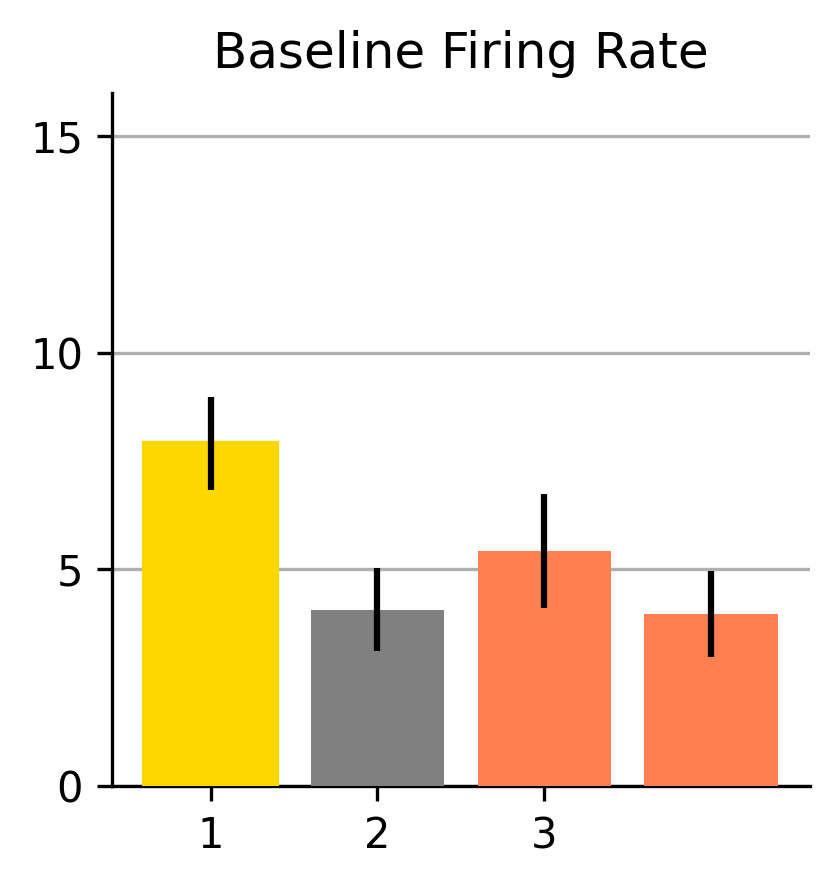

In [71]:
#Plotting Baseline FR
fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)

plt.bar(1,np.nanmedian(Pre_Light_Baseline),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(2,np.nanmedian(Pre_Dark_Baseline),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(3,np.nanmedian(Post_Light_Baseline),color = 'coral', label = 'Post-Dark',zorder = 5)
plt.bar(4,np.nanmedian(Post_Dark_Baseline),color = 'coral', label = 'Post-Dark',zorder = 5)

plt.errorbar(1,np.nanmedian(Pre_Light_Baseline),np.nanstd(Pre_Light_Baseline)/np.sqrt(len(Pre_Light_Baseline)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmedian(Pre_Dark_Baseline),np.nanstd(Pre_Dark_Baseline)/np.sqrt(len(Pre_Dark_Baseline)),color = 'black',zorder = 6)
plt.errorbar(3,np.nanmedian(Post_Light_Baseline),np.nanstd(Post_Light_Baseline)/np.sqrt(len(Post_Light_Baseline)),color = 'black',zorder = 6)
plt.errorbar(4,np.nanmedian(Post_Dark_Baseline),np.nanstd(Post_Dark_Baseline)/np.sqrt(len(Post_Dark_Baseline)),color = 'black',zorder = 6)
#plt.legend()
plt.yticks(ticks = [0,5,10,15])
plt.ylim(0,16)
plt.title('Baseline Firing Rate')
plt.grid(axis='y',zorder = 3)
plt.xticks(ticks = [1,2,3])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'PreLightDark_PostDark_medianBaseline_BarPlot.eps'),dpi=300)

In [63]:
from scipy.stats import friedmanchisquare
statistic, pvalue = friedmanchisquare(Pre_Light_Baseline, Pre_Dark_Baseline, Post_Dark_Baseline)
print(statistic, pvalue)

import scikit_posthocs as sp
sp.posthoc_dunn([Pre_Light_Baseline, Pre_Dark_Baseline, Post_Dark_Baseline], p_adjust = 'holm')

40.29885057471256 1.7750712262554084e-09


,1,2,3
1,1.000000,0.001284,0.001284
2,0.001284,1.000000,0.946487
3,0.001284,0.946487,1.000000


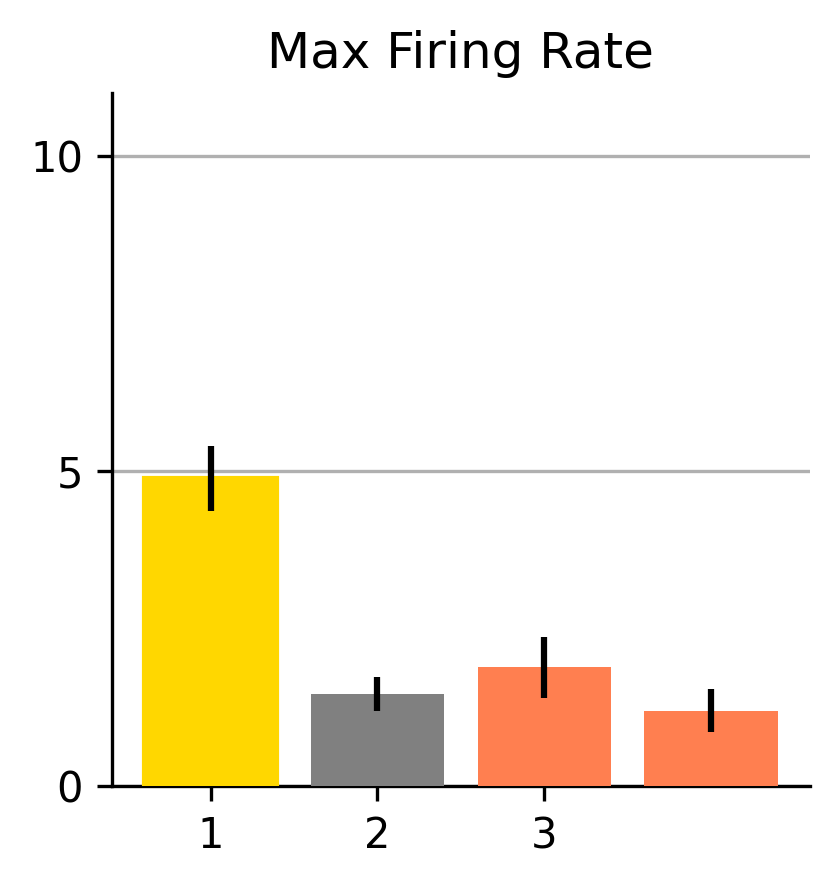

In [72]:
#Plotting Baseline FR

Pre_Light_Baselined = Pre_Light_Raw_Filtered - Pre_Light_Baseline[:,None]
Pre_Dark_Baselined = Pre_Dark_Raw_Filtered - Pre_Dark_Baseline[:,None]
Post_Light_Baselined = Post_Light_Raw_Filtered - Post_Light_Baseline[:,None]
Post_Dark_Baselined = Post_Dark_Raw_Filtered - Post_Dark_Baseline[:,None]

Pre_Light_Max = np.nanmax(Pre_Light_Baselined[:,1000:1350],axis=1)
Pre_Dark_Max = np.nanmax(Pre_Dark_Baselined[:,1000:1350],axis=1)
Post_Light_Max = np.nanmax(Post_Light_Baselined[:,1000:1350],axis=1)
Post_Dark_Max = np.nanmax(Post_Dark_Baselined[:,1000:1350],axis=1)

fig, axs=plt.subplots(1,1,figsize=(3,3), dpi=300)

plt.bar(1,np.nanmedian(Pre_Light_Max),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(2,np.nanmedian(Pre_Dark_Max),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(3,np.nanmedian(Post_Light_Max),color = 'coral', label = 'Post-Light',zorder = 5)
plt.bar(4,np.nanmedian(Post_Dark_Max),color = 'coral', label = 'Post-Dark',zorder = 5)

plt.errorbar(1,np.nanmedian(Pre_Light_Max),np.nanstd(Pre_Light_Max)/np.sqrt(len(Pre_Light_Max)),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmedian(Pre_Dark_Max),np.nanstd(Pre_Dark_Max)/np.sqrt(len(Pre_Dark_Max)),color = 'black',zorder = 6)
plt.errorbar(3,np.nanmedian(Post_Light_Max),np.nanstd(Post_Light_Max)/np.sqrt(len(Post_Light_Max)),color = 'black',zorder = 6)
plt.errorbar(4,np.nanmedian(Post_Dark_Max),np.nanstd(Post_Dark_Max)/np.sqrt(len(Post_Dark_Max)),color = 'black',zorder = 6)

#plt.legend()

plt.ylim(0,11)
plt.yticks(ticks = [0,5,10])
plt.title('Max Firing Rate')
plt.grid(axis='y',zorder = 3)
plt.xticks(ticks = [1,2,3])

plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'PreLightDark_PostDark_medianFR_BarPlot.eps'),dpi=300)

In [73]:
np.save(os.path.join(figpath, 'PreDarkBaseline.npy'), Pre_Dark_Baseline)
np.save(os.path.join(figpath, 'PostDarkBaseline.npy'), Post_Dark_Baseline)
np.save(os.path.join(figpath, 'PreLightBaseline.npy'), Pre_Light_Baseline)
np.save(os.path.join(figpath, 'PostLightBaseline.npy'), Post_Light_Baseline)

np.save(os.path.join(figpath, 'PreDarkMax.npy'), Pre_Dark_Max)
np.save(os.path.join(figpath, 'PostDarkMax.npy'), Post_Dark_Max)
np.save(os.path.join(figpath, 'PreLightMax.npy'), Pre_Light_Max)
np.save(os.path.join(figpath, 'PostLightMax.npy'), Post_Light_Max)

In [12]:
figpath

'G:\\My Drive\\Science Files\\Manuscripts\\DOI Project\\Figures\\Fig 7 - Dark Recordings'

In [65]:
from scipy.stats import friedmanchisquare
statistic, pvalue = friedmanchisquare(Pre_Light_Max,Pre_Dark_Max,Post_Dark_Max)
print(statistic, pvalue)

import scikit_posthocs as sp
sp.posthoc_dunn([Pre_Light_Max,Pre_Dark_Max,Post_Dark_Max], p_adjust = 'holm')

82.4565217391305 1.2439238819820292e-18


,1,2,3
1,1.000000e+00,7.625372e-11,2.398125e-14
2,7.625372e-11,1.000000e+00,2.256975e-01
3,2.398125e-14,2.256975e-01,1.000000e+00


In [ ]:
plasma_map = plt.cm.plasma(np.linspace(0,1,15))
clr = [plasma_map[12, :], plasma_map[5,:], plasma_map[8, :], plasma_map[10, :],plasma_map[2, :]]

In [ ]:

plt.plot(np.nanmean(Pre_Light_Norm,axis=0),color = 'gold',label = 'Pre-Light')
plt.plot(np.nanmean(Pre_Dark_Norm,axis=0),color = 'grey',label = 'Pre-Dark')
plt.plot(np.nanmean(Post_Dark_Norm,axis=0),color = 'coral',label = 'Post-Dark')
plt.legend()
plt.axvline(1000,color = 'black',linestyle = '--')
plt.xlim(750,1750)

In [47]:
PreDOI_Pref_Gaze_Norm_Lim_Light = Pre_Light_Norm.copy()
PreDOI_Pref_Gaze_Norm_Lim_Dark = Pre_Dark_Norm.copy()
PostDOI_Pref_Gaze_Norm_Lim_Dark = Post_Dark_Norm.copy()
PreDOI_NonPref_Gaze_Norm_Lim_Light = Pre_NonPref_Light_Norm.copy()
PreDOI_NonPref_Gaze_Norm_Lim_Dark = Pre_NonPref_Dark_Norm.copy()
PostDOI_NonPref_Gaze_Norm_Lim_Dark = Post_NonPref_Dark_Norm.copy()

Responsive = np.squeeze(np.isnan(PostDOI_Pref_Gaze_Norm_Lim_Dark[:,0]) == 0)

PreDOI_Pref_Gaze_Norm_Lim_Light = PreDOI_Pref_Gaze_Norm_Lim_Light[Responsive]
PreDOI_Pref_Gaze_Norm_Lim_Dark = PreDOI_Pref_Gaze_Norm_Lim_Dark[Responsive]
PostDOI_Pref_Gaze_Norm_Lim_Dark = PostDOI_Pref_Gaze_Norm_Lim_Dark[Responsive]

In [ ]:
Pre_Light_Baselined = Pre_Light_Raw_Filtered - Pre_Light_Baseline[:,None]
#Pre_Dark_Norm = Pre_Dark_Raw_Filtered - Pre_Dark_Baseline[:,None]
#Post_Dark_Norm = Post_Dark_Raw_Filtered - Post_Dark_Baseline[:,None]
Pre_NonPref_Light_Baselined = Pre_NonPref_Light_Filtered - Pre_NonPref_Light_Baseline[:,None]
#Pre_NonPref_Dark_Norm = Pre_NonPref_Dark_Filtered - Pre_NonPref_Dark_Baseline[:,None]
#Post_NonPref_Dark_Norm = Post_NonPref_Dark_Filtered - Post_NonPref_Dark_Baseline[:,None]


DSI = (np.nanmax((Pre_Light_Baselined[:,975:1250]),axis=1) - np.nanmax((Pre_NonPref_Light_Baselined[:,975:1250]),axis=1))/(np.nanmax((Pre_Light_Baselined[:,975:1250]),axis=1) + np.nanmax((Pre_NonPref_Light_Baselined[:,975:1250]),axis=1))

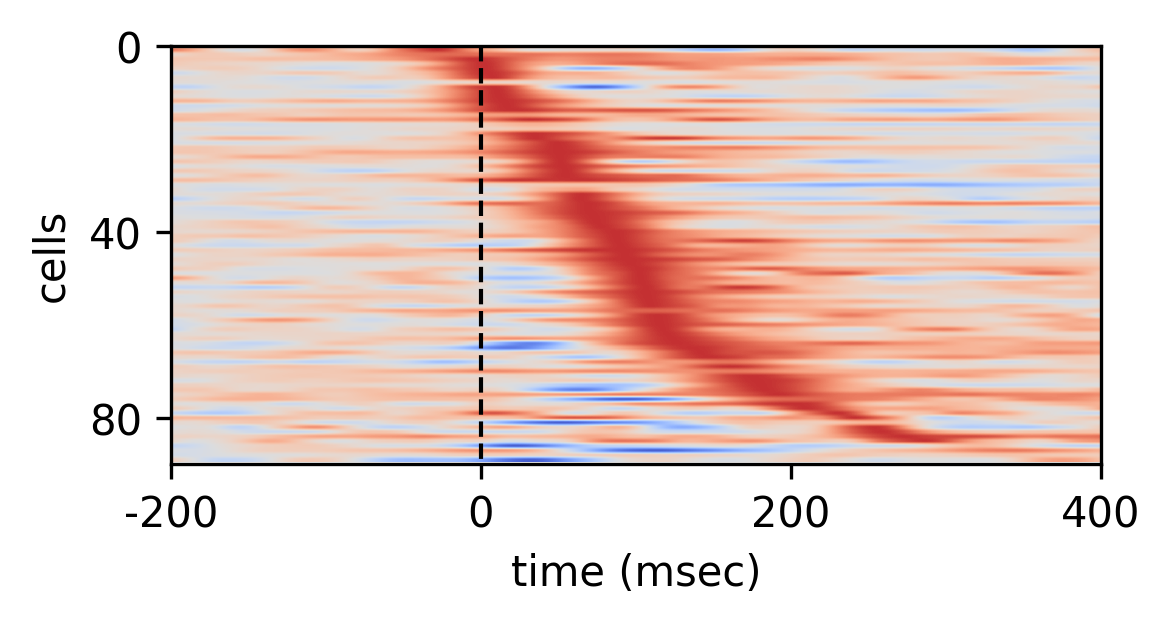

In [83]:

Pref_Gaze_PreLight_Latency = np.argmax(PreDOI_Pref_Gaze_Norm_Lim_Light[:,950:1350],axis=1)
Reshape_Mask_PreLight = np.argsort(Pref_Gaze_PreLight_Latency)
PreLight_DOI_Gaze_SortedbyPre = PreDOI_Pref_Gaze_Norm_Lim_Light[Reshape_Mask_PreLight,:]

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300)
_im = sacc.plot_PSTH_heatmap(ax, np.squeeze(PreLight_DOI_Gaze_SortedbyPre[:,:]), cscale=1.1)
ax.set_aspect(3)
#plt.colorbar(ax=ax, mappable=_im)
plt.yticks(ticks=[0,40,80])
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath,'PreDOI_Light_GazeRipple.eps'),dpi=300)

In [ ]:
#NonPref_Gaze_PreLight_Latency = np.argmax(PreDOI_NonPref_Gaze_Norm_Lim_Light[:,1025:1500],axis=1)
#Reshape_Mask_PreLight = np.argsort(NonPref_Gaze_PreLight_Latency)
PreLight_DOI_NonPref_Gaze_SortedbyPre = PreDOI_NonPref_Gaze_Norm_Lim_Light[Reshape_Mask_PreLight,:]

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300)
_im = sacc.plot_PSTH_heatmap(ax, np.squeeze(PreLight_DOI_NonPref_Gaze_SortedbyPre[:,:]), cscale=1)
ax.set_aspect(3)
#plt.colorbar(ax=ax, mappable=_im)
plt.yticks(ticks=[0,50,100])
plt.gca().set_rasterized(True)
#fig.savefig(os.path.join(figpath,'PreDOI_Light_NonPref_GazeRipple.eps'),dpi=300)

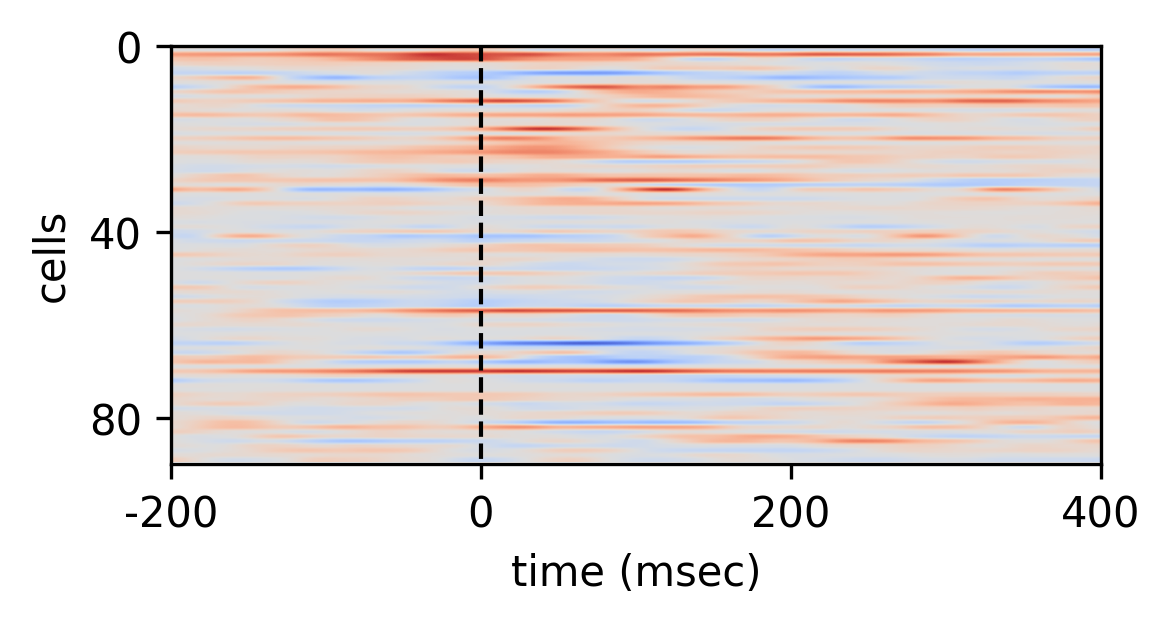

In [84]:

PreDark_DOI_Gaze_SortedbyPre = PreDOI_Pref_Gaze_Norm_Lim_Dark[Reshape_Mask_PreLight,:]

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300)
_im = sacc.plot_PSTH_heatmap(ax, np.squeeze(PreDark_DOI_Gaze_SortedbyPre[:,:]), cscale=1.1)
ax.set_aspect(3)
#plt.colorbar(ax=ax, mappable=_im)
plt.yticks(ticks=[0,40,80])
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath,'PreDOI_Dark_GazeRipple.eps'),dpi=300)

In [ ]:

PreDark_DOI_NonPref_Gaze_SortedbyPre = PreDOI_NonPref_Gaze_Norm_Lim_Dark[Reshape_Mask_PreLight,:]

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300)
_im = sacc.plot_PSTH_heatmap(ax, np.squeeze(PreDark_DOI_NonPref_Gaze_SortedbyPre[:,:]), cscale=1.1)
ax.set_aspect(2)
#plt.colorbar(ax=ax, mappable=_im)
plt.yticks(ticks=[0,40,80])
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath,'PreDOI_Dark_NonPref_GazeRipple.eps'),dpi=300)

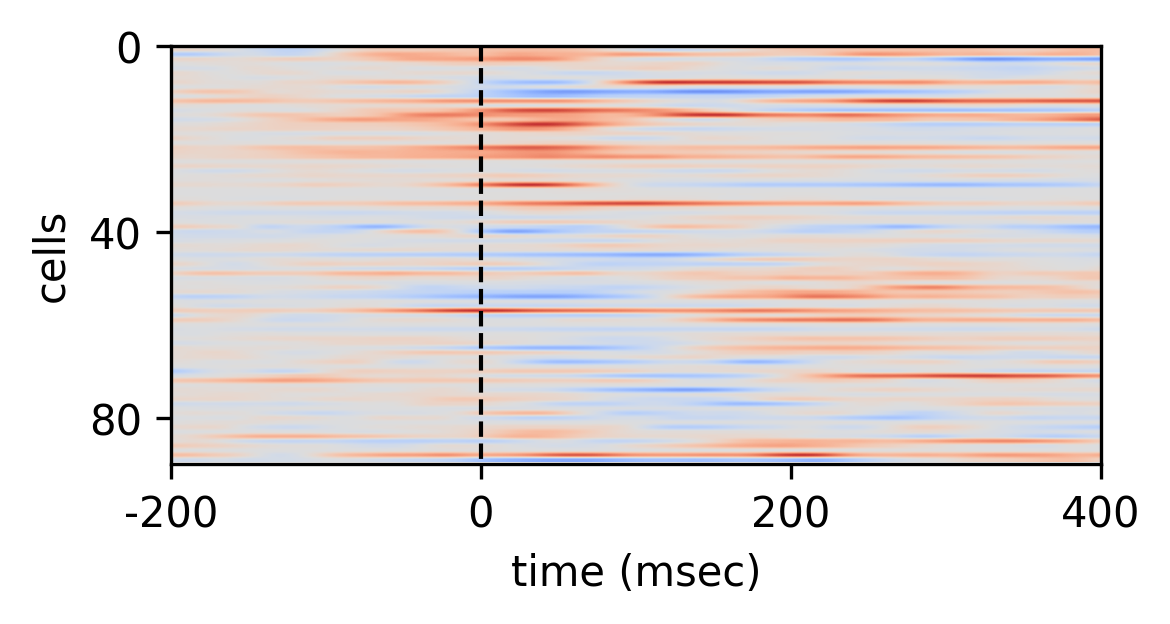

In [85]:


PostDark_DOI_Gaze_SortedbyPre = PostDOI_Pref_Gaze_Norm_Lim_Dark[Reshape_Mask_PreLight,:]

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300)
_im = sacc.plot_PSTH_heatmap(ax, np.squeeze(PostDark_DOI_Gaze_SortedbyPre[:,:]), cscale=1.1)
ax.set_aspect(3)
plt.yticks(ticks=[0,40,80])
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath,'PostDOI_Dark_GazeRipple.eps'),dpi=300)

In [ ]:


PostDark_DOI_NonPref_Gaze_SortedbyPre = PostDOI_NonPref_Gaze_Norm_Lim_Dark[Reshape_Mask_PreLight,:]

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=300)
_im = sacc.plot_PSTH_heatmap(ax, np.squeeze(PostDark_DOI_NonPref_Gaze_SortedbyPre[:,:]), cscale=1.1)
ax.set_aspect(2)
plt.yticks(ticks=[0,70,140])
plt.gca().set_rasterized(True)
fig.savefig(os.path.join(figpath,'PostDOI_Dark_NonPref_GazeRipple.eps'),dpi=300)


In [12]:
Pre_Light_4_Clust = Pre_Light_Norm.copy()

#Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)


proj = pca.transform(Pre_Light_4_Clust[:, 950:1300])  # Transform into PC space.
gproj = proj[:,:4]  # Only keep required PCs
PreDOI_Labels = kmeans_model.predict(gproj)  # Map onto k-means clusters.

#PreDOI_Labels_Limited = PreDOI_Labels[Pre_Light_Responsive.astype(bool)]

In [ ]:
for ii in list(range(0,len(Pre_Light_Raw[Pre_Light_Responsive.astype(bool)]))):

    fig, axs = plt.subplots(1,1)

    plt.plot(Pre_Light_Raw[ii,:],color = 'gold')
    plt.plot(Pre_Dark_Raw[ii,:],color = 'black')
    plt.plot(Post_Dark_Raw[ii,:],color = 'coral')

    plt.axhline(Pre_Light_Baseline[ii],color = 'gold',linestyle='--')
    plt.axhline(Pre_Dark_Baseline[ii],color = 'black',linestyle='--')
    plt.axhline(Post_Dark_Baseline[ii],color = 'coral',linestyle='--')

    plt.savefig('D:\PrePostDOI\Dark vs Light Plots\Cell_' + str(ii) + '.png',bbox_inches='tight')
    plt.close()
    #

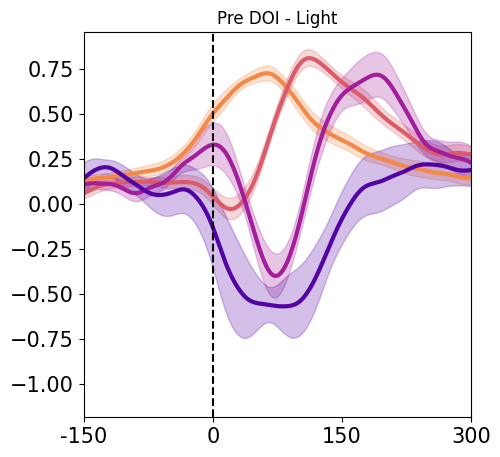

In [70]:


Pre_Light_Early_Mean = np.squeeze(np.nanmean(Pre_Light_Norm[np.argwhere(PreDOI_Labels==3),:],axis = 0))
Pre_Light_Late_Mean = np.squeeze(np.nanmean(Pre_Light_Norm[np.argwhere(PreDOI_Labels==2),:],axis = 0))
Pre_Light_Biphasic_Mean = np.squeeze(np.nanmean(Pre_Light_Norm[np.argwhere(PreDOI_Labels==1),:],axis = 0))
Pre_Light_Negative_Mean = np.squeeze(np.nanmean(Pre_Light_Norm[np.argwhere(PreDOI_Labels==4),:],axis = 0))

Pre_Light_Early_STE = np.squeeze(np.nanstd(Pre_Light_Norm[np.argwhere(PreDOI_Labels==3),:],axis = 0)/np.sqrt(len(Pre_Light_Norm[np.argwhere(PreDOI_Labels==3),:])))
Pre_Light_Late_STE = np.squeeze(np.nanstd(Pre_Light_Norm[np.argwhere(PreDOI_Labels==2),:],axis = 0)/np.sqrt(len(Pre_Light_Norm[np.argwhere(PreDOI_Labels==2),:])))
Pre_Light_Biphasic_STE = np.squeeze(np.nanstd(Pre_Light_Norm[np.argwhere(PreDOI_Labels==1),:],axis = 0)/np.sqrt(len(Pre_Light_Norm[np.argwhere(PreDOI_Labels==1),:])))
Pre_Light_Negative_STE = np.squeeze(np.nanstd(Pre_Light_Norm[np.argwhere(PreDOI_Labels==4),:],axis = 0)/np.sqrt(len(Pre_Light_Norm[np.argwhere(PreDOI_Labels==4),:])))

import matplotlib.pyplot as plt
import numpy as np

plasma_map = plt.cm.plasma(np.linspace(0,1,15))

# Function to plot mean and standard deviation for each group
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.25)
    #plt.legend()

# Plotting mean and standard deviation for each group before DOI
plt.figure(figsize=(5,5))
for group_mean, group_std, color, label in zip([ Pre_Light_Early_Mean, Pre_Light_Late_Mean, Pre_Light_Biphasic_Mean, Pre_Light_Negative_Mean],
                                                [Pre_Light_Early_STE, Pre_Light_Late_STE, Pre_Light_Biphasic_STE, Pre_Light_Negative_STE],
                                                [ plasma_map[10, :], plasma_map[8, :], plasma_map[5,:], plasma_map[2, :]],
                                                ['Early', 'Late', 'Biphasic', 'Negative']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.title('Pre DOI - Light')
plt.xlim(850, 1300)
plt.xticks([850, 1000, 1150, 1300], labels=[-150, 0, 150, 300], fontsize = 15)
#plt.yticks([-.5,0,.5,1],  fontsize = 15)
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
#plt.ylim(-1,1)  # Setting y-axis limit
plt.axvline(x=1000, color='black', linestyle='--')  # Vertical dashed line at x=0
plt.show()


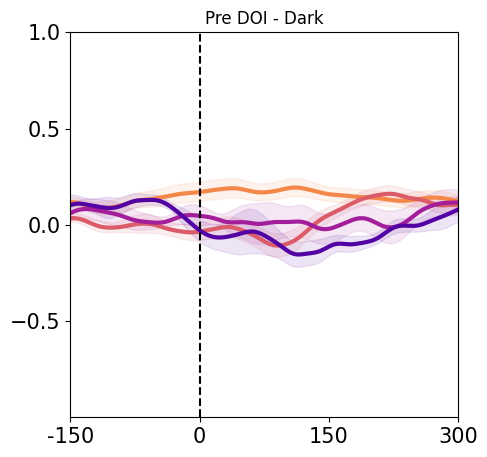

In [71]:
Pre_Dark_Early_Mean = np.squeeze(np.nanmean(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==3),:],axis = 0))
Pre_Dark_Late_Mean = np.squeeze(np.nanmean(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==2),:],axis = 0))
Pre_Dark_Biphasic_Mean = np.squeeze(np.nanmean(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==1),:],axis = 0))
Pre_Dark_Negative_Mean = np.squeeze(np.nanmean(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==4),:],axis = 0))

Pre_Dark_Early_STE = np.squeeze(np.nanstd(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==3),:],axis = 0)/np.sqrt(len(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==3),:])))
Pre_Dark_Late_STE = np.squeeze(np.nanstd(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==2),:],axis = 0)/np.sqrt(len(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==2),:])))
Pre_Dark_Biphasic_STE = np.squeeze(np.nanstd(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==1),:],axis = 0)/np.sqrt(len(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==1),:])))
Pre_Dark_Negative_STE = np.squeeze(np.nanstd(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==4),:],axis = 0)/np.sqrt(len(Pre_Dark_Norm[np.argwhere(PreDOI_Labels==4),:])))

import matplotlib.pyplot as plt
import numpy as np

#These plots are the same as above except that I had chatgpt simplify the code by adding for loops to iterate over the variables so that I could more 
#easily change the code to incorporate the matching color scheme

plasma_map = plt.cm.plasma(np.linspace(0,1,15))

# Function to plot mean and standard deviation for each group
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.1)
    #plt.legend()

# Plotting mean and standard deviation for each group before DOI
plt.figure(figsize=(5,5))
for group_mean, group_std, color, label in zip([ Pre_Dark_Early_Mean, Pre_Dark_Late_Mean, Pre_Dark_Biphasic_Mean, Pre_Dark_Negative_Mean],
                                                [Pre_Dark_Early_STE, Pre_Dark_Late_STE, Pre_Dark_Biphasic_STE, Pre_Dark_Negative_STE],
                                                [ plasma_map[10, :], plasma_map[8, :], plasma_map[5,:], plasma_map[2, :]],
                                                ['Early', 'Late', 'Biphasic', 'Negative']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.title('Pre DOI - Dark')
plt.xlim(850, 1300)
plt.xticks([850, 1000, 1150, 1300], labels=[-150, 0, 150, 300], fontsize = 15)
plt.yticks([-.5,0,.5,1],  fontsize = 15)
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
plt.ylim(-1,1)   # Setting y-axis limit
plt.axvline(x=1000, color='black', linestyle='--')  # Vertical dashed line at x=0
plt.show()

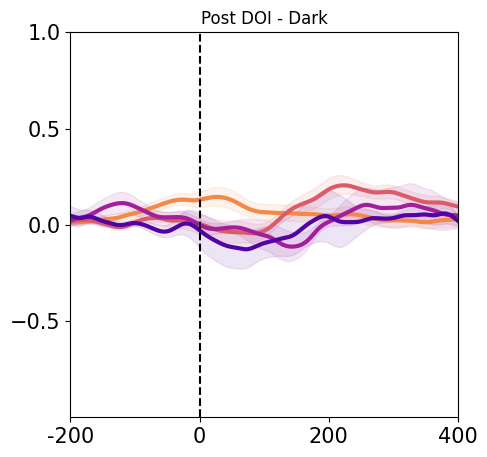

In [72]:
Post_Dark_Early_Mean = np.squeeze(np.nanmean(Post_Dark_Norm[np.argwhere(PreDOI_Labels==3),:],axis = 0))
Post_Dark_Late_Mean = np.squeeze(np.nanmean(Post_Dark_Norm[np.argwhere(PreDOI_Labels==2),:],axis = 0))
Post_Dark_Biphasic_Mean = np.squeeze(np.nanmean(Post_Dark_Norm[np.argwhere(PreDOI_Labels==1),:],axis = 0))
Post_Dark_Negative_Mean = np.squeeze(np.nanmean(Post_Dark_Norm[np.argwhere(PreDOI_Labels==4),:],axis = 0))

Post_Dark_Early_STE = np.squeeze(np.nanstd(Post_Dark_Norm[np.argwhere(PreDOI_Labels==3),:],axis = 0)/np.sqrt(len(Post_Dark_Norm[np.argwhere(PreDOI_Labels==3),:])))
Post_Dark_Late_STE = np.squeeze(np.nanstd(Post_Dark_Norm[np.argwhere(PreDOI_Labels==2),:],axis = 0)/np.sqrt(len(Post_Dark_Norm[np.argwhere(PreDOI_Labels==2),:])))
Post_Dark_Biphasic_STE = np.squeeze(np.nanstd(Post_Dark_Norm[np.argwhere(PreDOI_Labels==1),:],axis = 0)/np.sqrt(len(Post_Dark_Norm[np.argwhere(PreDOI_Labels==1),:])))
Post_Dark_Negative_STE = np.squeeze(np.nanstd(Post_Dark_Norm[np.argwhere(PreDOI_Labels==4),:],axis = 0)/np.sqrt(len(Post_Dark_Norm[np.argwhere(PreDOI_Labels==4),:])))

import matplotlib.pyplot as plt
import numpy as np

#These plots are the same as above except that I had chatgpt simplify the code by adding for loops to iterate over the variables so that I could more 
#easily change the code to incorporate the matching color scheme

plasma_map = plt.cm.plasma(np.linspace(0,1,15))

# Function to plot mean and standard deviation for each group
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.1)
    #plt.legend()

# Plotting mean and standard deviation for each group before DOI
plt.figure(figsize=(5,5))
for group_mean, group_std, color, label in zip([ Post_Dark_Early_Mean, Post_Dark_Late_Mean, Post_Dark_Biphasic_Mean, Post_Dark_Negative_Mean],
                                                [Post_Dark_Early_STE, Post_Dark_Late_STE, Post_Dark_Biphasic_STE, Post_Dark_Negative_STE],
                                                [ plasma_map[10, :], plasma_map[8, :], plasma_map[5,:], plasma_map[2, :]],
                                                ['Early', 'Late', 'Biphasic', 'Negative']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.title('Post DOI - Dark')
plt.xlim(800, 1400)
plt.xticks([800, 1000, 1200, 1400], labels=[-200, 0, 200, 400], fontsize = 15)
plt.yticks([-.5,0,.5,1],  fontsize = 15)
plt.yticks(fontsize=15)  # Adjusting font size for y-axis ticks
plt.ylim(-1,1)  # Setting y-axis limit
plt.axvline(x=1000, color='black', linestyle='--')  # Vertical dashed line at x=0
plt.show()


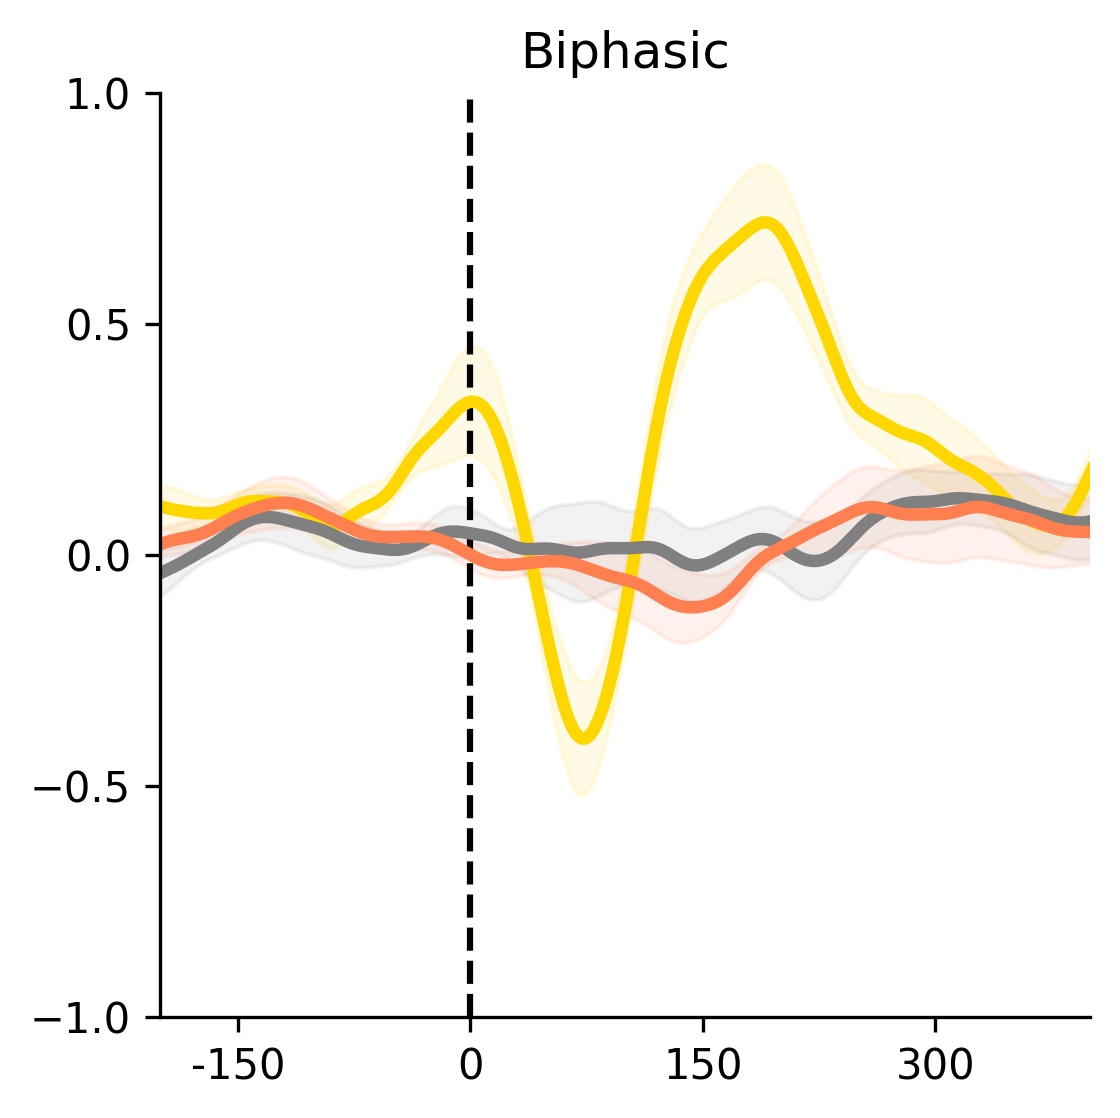

In [100]:
def plot_group_mean_std(group_mean, group_std, color, label):
    plt.plot(group_mean, c=color, label=label, linewidth=3)
    plt.fill_between(range(len(group_mean)), group_mean - group_std, group_mean + group_std, color=color, alpha=0.1)
    #plt.legend()

fig, axs=plt.subplots(1,1,figsize=(4,4), dpi=300)
plt.axvline(x=1000, color='black', linestyle='--')  
for group_mean, group_std, color, label in zip([Pre_Light_Biphasic_Mean, Pre_Dark_Biphasic_Mean, Post_Dark_Biphasic_Mean],
                                                [Pre_Light_Biphasic_STE, Pre_Dark_Biphasic_STE, Post_Dark_Biphasic_STE],
                                                ['gold','grey','coral'],
                                                ['Pre-Light','Pre-Dark','Post-Dark']):
    plot_group_mean_std(group_mean, group_std, color, label)
plt.title('Biphasic')

plt.xlim(800, 1400)
plt.xticks([850, 1000, 1150, 1300], labels=[-150, 0, 150, 300])
plt.ylim([-1,1])
plt.yticks(ticks= np.arange(-1,1.5,.5))
plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)
plt.show()
fig.savefig(os.path.join(figpath,'PreLightDark_PostDark_BiphasicAverage.eps'),dpi=300)


In [ ]:


plt.plot(Pre_Light_Norm[np.squeeze(np.argwhere(PreDOI_Labels_Lim==1)),:].T)

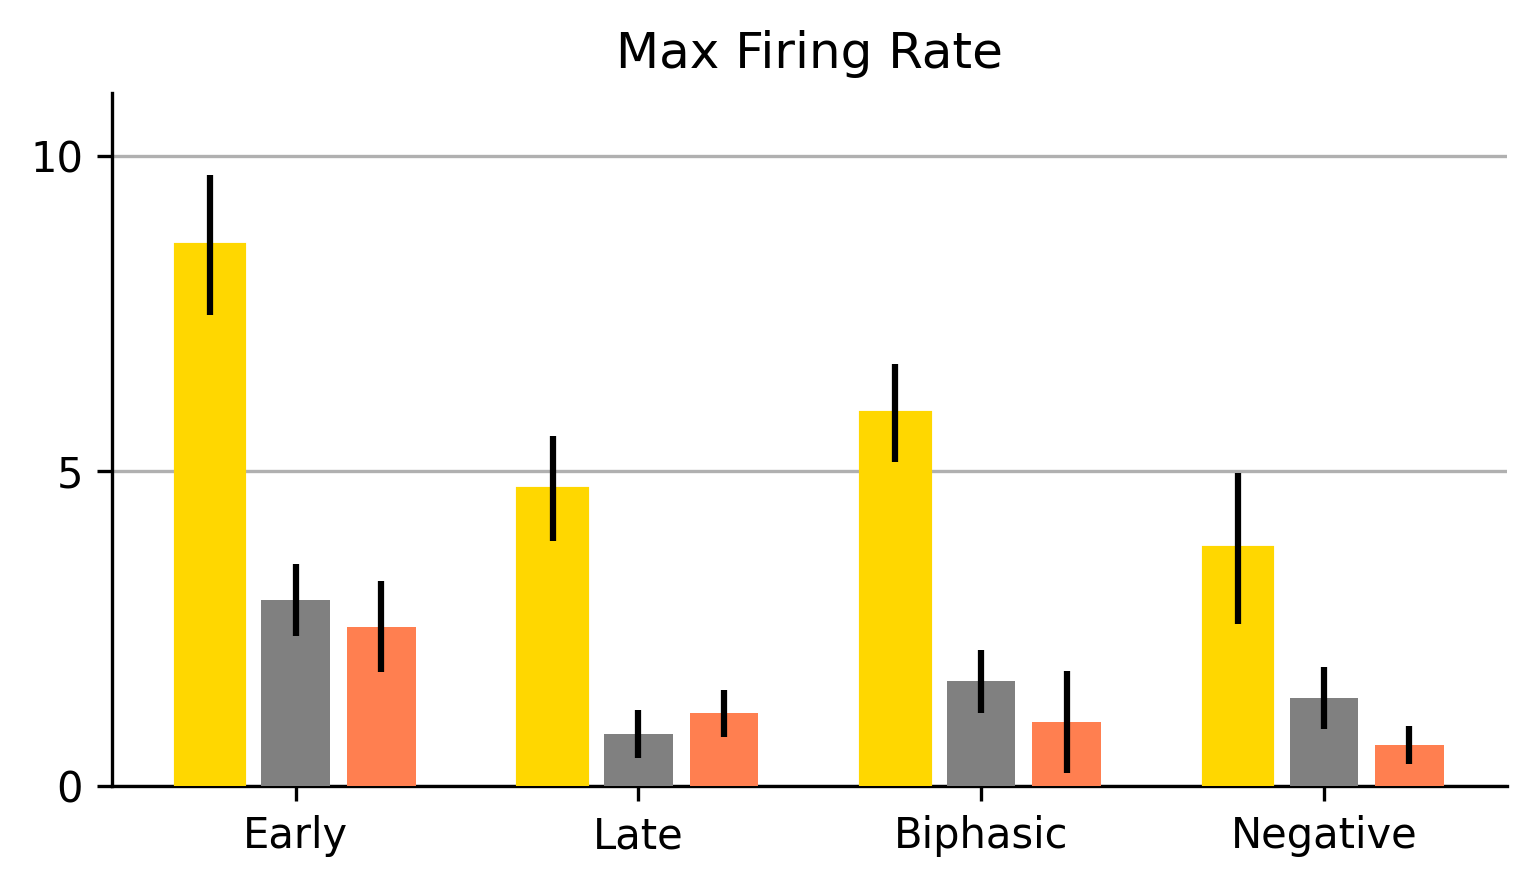

In [15]:
#Plotting mAX FR BY CLUSTER
Responsive = np.squeeze(np.isnan(Post_Dark_Max[:]) == 0) 
 
Pre_Light_Baselined = Pre_Light_Raw_Filtered - Pre_Light_Baseline[:,None]
Pre_Dark_Baselined = Pre_Dark_Raw_Filtered - Pre_Dark_Baseline[:,None]
Post_Dark_Baselined = Post_Dark_Raw_Filtered - Post_Dark_Baseline[:,None]

Pre_Light_Max = np.nanmax(np.abs(Pre_Light_Baselined[:,1000:1350]),axis=1)
#Pre_Light_Max = Pre_Light_Max[Responsive]

Pre_Dark_Max = np.nanmax(np.abs(Pre_Dark_Baselined[:,1000:1350]),axis=1)
#Pre_Dark_Max = Pre_Dark_Max[Responsive]


Post_Dark_Max = np.nanmax(np.abs(Post_Dark_Baselined[:,1000:1350]),axis=1)
#Post_Dark_Max = Post_Dark_Max[Responsive]


#Responsive = np.squeeze(np.isnan(Post_Dark_Max[:]) == 0)
Pre_Light_Max_Lim = Pre_Light_Max[Responsive]
Pre_Dark_Max_Lim = Pre_Dark_Max[Responsive]
Post_Dark_Max_Lim = Post_Dark_Max[Responsive]
PreDOI_Labels_Lim = PreDOI_Labels[Responsive]



fig, axs=plt.subplots(1,1,figsize=(6,3), dpi=300)

plt.bar(1,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(2,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(3,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),color = 'coral', label = 'Post-Dark',zorder = 5)
plt.errorbar(1,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),np.nanstd(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)])/np.sqrt(len(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)])),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),np.nanstd(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)])/np.sqrt(len(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)])),color = 'black',zorder = 6)
plt.errorbar(3,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),np.nanstd(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)])/np.sqrt(len(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==3)])),color = 'black',zorder = 6)

plt.bar(5,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),edgecolor = 'gold',color = 'gold',zorder = 5)
plt.bar(6,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),color = 'grey',zorder = 5)
plt.bar(7,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),color = 'coral',zorder = 5)
plt.errorbar(5,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),np.nanstd(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)])/np.sqrt(len(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)])),color = 'black',zorder = 6)
plt.errorbar(6,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),np.nanstd(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)])/np.sqrt(len(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)])),color = 'black',zorder = 6)
plt.errorbar(7,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),np.nanstd(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)])/np.sqrt(len(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==2)])),color = 'black',zorder = 6)

plt.bar(9,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),edgecolor = 'gold',color = 'gold',zorder = 5)
plt.bar(10,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),color = 'grey',zorder = 5)
plt.bar(11,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),color = 'coral', zorder = 5)
plt.errorbar(9,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),np.nanstd(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)])/np.sqrt(len(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)])),color = 'black',zorder = 6)
plt.errorbar(10,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),np.nanstd(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)])/np.sqrt(len(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)])),color = 'black',zorder = 6)
plt.errorbar(11,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),np.nanstd(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)])/np.sqrt(len(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==1)])),color = 'black',zorder = 6)

plt.bar(13,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),edgecolor = 'gold',color = 'gold',zorder = 5)
plt.bar(14,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),color = 'grey',zorder = 5)
plt.bar(15,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),color = 'coral', zorder = 5)
plt.errorbar(13,np.nanmedian(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),np.nanstd(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)])/np.sqrt(len(Pre_Light_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)])),color = 'black',zorder = 6)
plt.errorbar(14,np.nanmedian(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),np.nanstd(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)])/np.sqrt(len(Pre_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)])),color = 'black',zorder = 6)
plt.errorbar(15,np.nanmedian(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),np.nanstd(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)])/np.sqrt(len(Post_Dark_Max_Lim[np.argwhere(PreDOI_Labels_Lim==4)])),color = 'black',zorder = 6)

#plt.legend()
plt.ylim(0,11)
plt.yticks(ticks = [0,5,10])
plt.xticks(ticks = [2,6,10,14],labels=['Early', 'Late','Biphasic','Negative'])
plt.title('Max Firing Rate')
plt.grid(axis='y',zorder = 3)


plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'MaxGazeShiftResponseByCluster.eps'),dpi=300)


In [41]:
statistic, pvalue = friedmanchisquare(Pre_Light_Max_Lim,Pre_Dark_Max_Lim,Post_Dark_Max_Lim)
print(statistic, pvalue)

import scikit_posthocs as sp
sp.posthoc_dunn([Pre_Light_Max_Lim,Pre_Dark_Max_Lim,Post_Dark_Max_Lim], p_adjust = 'holm')

92.31460674157302 8.99783130410328e-21


,1,2,3
1,1.000000e+00,7.338973e-11,9.112365e-12
2,7.338973e-11,1.000000e+00,7.194931e-01
3,9.112365e-12,7.194931e-01,1.000000e+00


In [74]:
from scipy.stats import friedmanchisquare
clust = 4

statistic, pvalue = friedmanchisquare(Pre_Light_Max_Lim[np.where(PreDOI_Labels_Lim==clust)],Pre_Dark_Max_Lim[np.where(PreDOI_Labels_Lim==clust)],Post_Dark_Max_Lim[np.where(PreDOI_Labels_Lim==clust)])
print(statistic, pvalue)

import scikit_posthocs as sp
sp.posthoc_dunn([np.squeeze(Pre_Light_Max_Lim[np.where(PreDOI_Labels_Lim==clust)]),np.squeeze(Pre_Dark_Max_Lim[np.where(PreDOI_Labels_Lim==clust)]),np.squeeze(Post_Dark_Max_Lim[np.where(PreDOI_Labels_Lim==clust)])], p_adjust = 'holm')


7.6000000000000085 0.0223707718561655


,1,2,3
1,1.000000,0.239590,0.039985
2,0.239590,1.000000,0.357971
3,0.039985,0.357971,1.000000


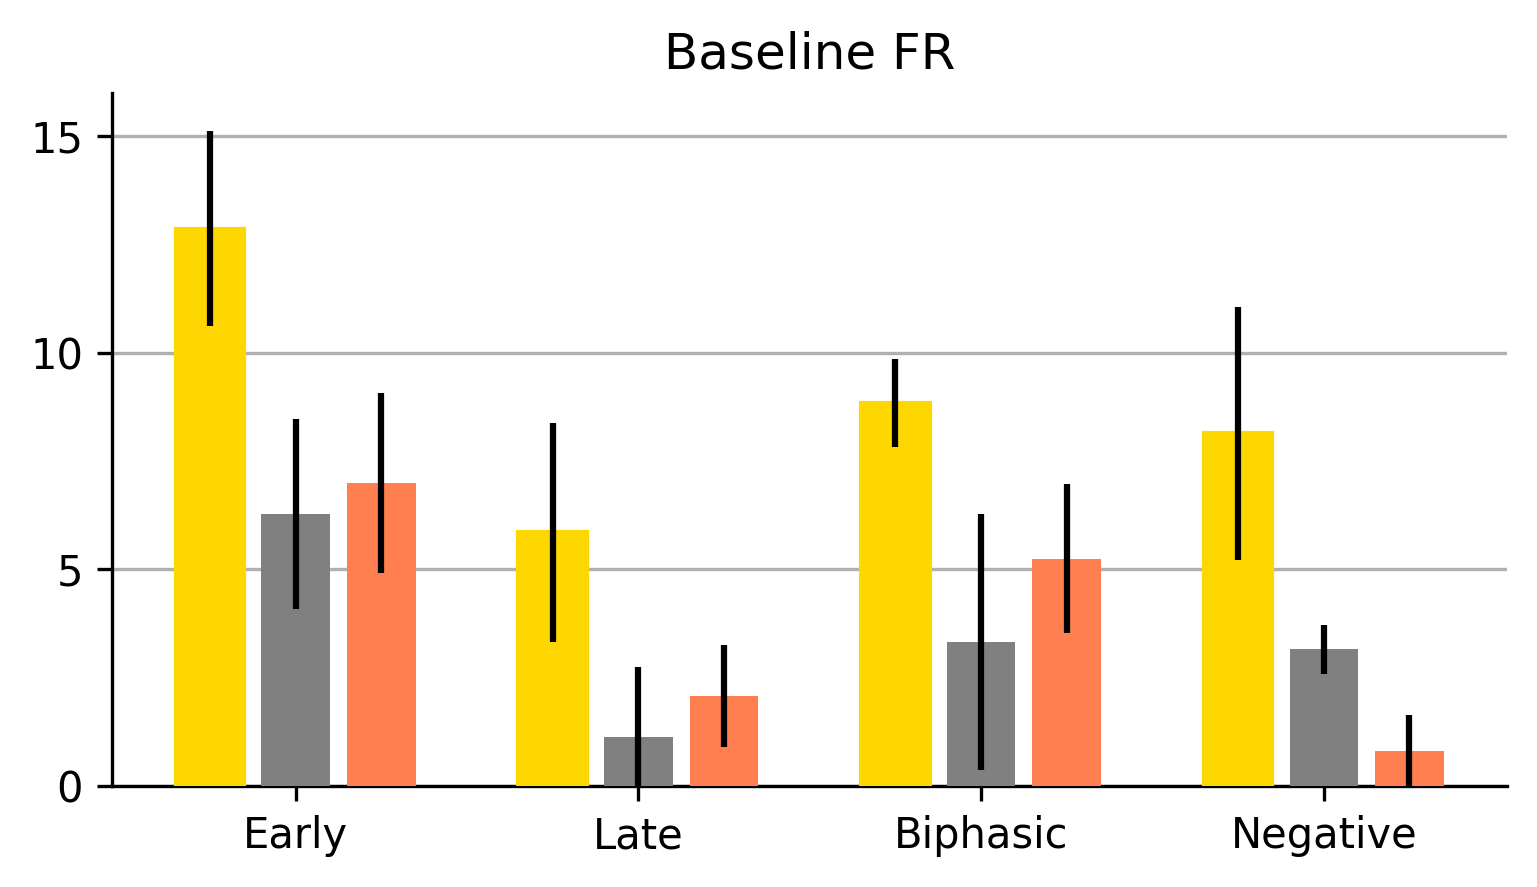

In [30]:
#Plotting baseline FR BY CLUSTER 

Pre_Light_Baseline_Lim = Pre_Light_Baseline[Responsive]
Pre_Dark_Baseline_Lim = Pre_Dark_Baseline[Responsive]
Post_Dark_Baseline_Lim = Post_Dark_Baseline[Responsive]
PreDOI_Labels_Lim = PreDOI_Labels[Responsive]



fig, axs=plt.subplots(1,1,figsize=(6,3), dpi=300)


plt.bar(1,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(2,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(3,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),color = 'coral', label = 'Post-Dark',zorder = 5)
plt.errorbar(1,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),np.nanstd(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)])/np.sqrt(len(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)])),color = 'black',zorder = 6)
plt.errorbar(2,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),np.nanstd(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)])/np.sqrt(len(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)])),color = 'black',zorder = 6)
plt.errorbar(3,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)]),np.nanstd(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)])/np.sqrt(len(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==3)])),color = 'black',zorder = 6)

plt.bar(5,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(6,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(7,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),color = 'coral', label = 'Post-Dark',zorder = 5)
plt.errorbar(5,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),np.nanstd(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)])/np.sqrt(len(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)])),color = 'black',zorder = 6)
plt.errorbar(6,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),np.nanstd(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)])/np.sqrt(len(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)])),color = 'black',zorder = 6)
plt.errorbar(7,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)]),np.nanstd(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)])/np.sqrt(len(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==2)])),color = 'black',zorder = 6)

plt.bar(9,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(10,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(11,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),color = 'coral', label = 'Post-Dark',zorder = 5)
plt.errorbar(9,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),np.nanstd(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)])/np.sqrt(len(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)])),color = 'black',zorder = 6)
plt.errorbar(10,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),np.nanstd(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)])/np.sqrt(len(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)])),color = 'black',zorder = 6)
plt.errorbar(11,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)]),np.nanstd(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)])/np.sqrt(len(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==1)])),color = 'black',zorder = 6)

plt.bar(13,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),edgecolor = 'gold',color = 'gold',label = 'Pre-Light',zorder = 5)
plt.bar(14,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),color = 'grey',label = 'Pre-Dark',zorder = 5)
plt.bar(15,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),color = 'coral', label = 'Post-Dark',zorder = 5)
plt.errorbar(13,np.nanmedian(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),np.nanstd(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)])/np.sqrt(len(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)])),color = 'black',zorder = 6)
plt.errorbar(14,np.nanmedian(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),np.nanstd(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)])/np.sqrt(len(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)])),color = 'black',zorder = 6)
plt.errorbar(15,np.nanmedian(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)]),np.nanstd(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)])/np.sqrt(len(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==4)])),color = 'black',zorder = 6)



plt.yticks(ticks = [0,5,10,15])
plt.ylim(0,16)
plt.xticks(ticks = [2,6,10,14],labels=['Early', 'Late','Biphasic','Negative'])
plt.title('Baseline FR')
plt.grid(axis='y',zorder = 3)


plt.gca().set_rasterized(True)
plt.gca().spines.top.set_visible(False)
plt.gca().spines.right.set_visible(False)

#fig.savefig(os.path.join(figpath,'BaselineFRResponseByCluster.eps'),dpi=300)



In [73]:
from scipy.stats import friedmanchisquare
clust = 3

statistic, pvalue = friedmanchisquare(np.squeeze(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==clust)]),np.squeeze(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==clust)]),np.squeeze(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==clust)]))
print(statistic, pvalue)

import scikit_posthocs as sp
print(sp.posthoc_dunn([np.squeeze(Pre_Light_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==clust)]),np.squeeze(Pre_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==clust)]),np.squeeze(Post_Dark_Baseline_Lim[np.argwhere(PreDOI_Labels_Lim==clust)])], p_adjust = 'holm'))


20.1395348837209 4.234045940830584e-05
          1         2         3
1  1.000000  0.207528  0.097688
2  0.207528  1.000000  0.609658
3  0.097688  0.609658  1.000000
